# 03 — Modelagem

Serão comparados cinco classificadores: Regressão Logística, Árvore de Decisão, KNN, SVM linear e Random Forest.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
PROCESSED = Path("..") / "data" / "processed"
RESULTS = Path("..") / "results"
FIGURES = RESULTS / "figures"
METRICS_DIR = RESULTS / "metrics"
TARGET = "TARGET"

FIGURES.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
print("Dimensões:", df.shape)
display(df.head())
print("Distribuição do alvo:")
display(df[TARGET].value_counts(normalize=True).rename("proporcao").to_frame())

Dimensões: (36457, 18)


,ID,GENERO,POSSUI_CARRO,POSSUI_IMOVEL,NUM_FILHOS,RENDA_ANUAL,TIPO_RENDA,ESCOLARIDADE,ESTADO_CIVIL,TIPO_MORADIA,TELEFONE_TRABALHO,TELEFONE,POSSUI_EMAIL,OCUPACAO,TAMANHO_FAMILIA,TARGET,IDADE_ANOS,TEMPO_TRABALHO_ANOS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Outros,2.0,0,32.867899,12.435318
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Outros,2.0,0,32.867899,12.435318
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Outros,2.0,0,58.792608,3.104723
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,0,52.320329,8.353183
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,0,52.320329,8.353183


Distribuição do alvo:


,proporcao
TARGET,
0,0.983103
1,0.016897


## 1. Separando treino e teste por perfil

Perfis com os mesmos valores de entrada ficam juntos no treino ou no teste. A base tem 9.728 perfis diferentes; 269 deles aparecem com os dois valores de `TARGET`, somando 1.574 clientes. Isso mostra que os dados cadastrais não bastam para distinguir todos os comportamentos de pagamento. A divisão em cinco partes deixa cerca de 20% dos perfis para o teste, sem compartilhar perfis entre treino e teste. `TARGET = 0` indica que não houve atraso de 60 dias ou mais no histórico observado; `TARGET = 1` indica que houve ao menos um atraso desse tipo.

In [3]:
from sklearn.model_selection import StratifiedGroupKFold

X = df.drop(columns=[TARGET, "ID"])
y = df[TARGET].astype(int)

# Perfis com os mesmos valores de entrada recebem o mesmo grupo.
profile_groups = pd.Series(
    pd.MultiIndex.from_frame(X).factorize(sort=False)[0],
    index=X.index,
    name="perfil",
)
perfil_resumo = pd.DataFrame({"perfil": profile_groups, TARGET: y}).groupby("perfil").agg(
    clientes=(TARGET, "size"),
    alvos_diferentes=(TARGET, "nunique"),
)
perfis_repetidos = perfil_resumo[perfil_resumo["clientes"] > 1]
perfis_conflitantes = perfil_resumo[perfil_resumo["alvos_diferentes"] > 1]
analise_perfis_repetidos = pd.DataFrame([{
    "Clientes": len(df),
    "Perfis únicos": len(perfil_resumo),
    "Perfis repetidos": len(perfis_repetidos),
    "Clientes em perfis repetidos": int(perfis_repetidos["clientes"].sum()),
    "Perfis com alvos diferentes": len(perfis_conflitantes),
    "Clientes em perfis com alvos diferentes": int(perfis_conflitantes["clientes"].sum()),
}])
display(analise_perfis_repetidos)
analise_perfis_repetidos.to_csv(METRICS_DIR / "analise_perfis_repetidos.csv", index=False)

# Perfis iguais ficam no mesmo conjunto para testar combinações que o modelo não viu.
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_indices, test_indices = next(splitter.split(X, y, groups=profile_groups))
X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]
groups_train = profile_groups.iloc[train_indices]
groups_test = profile_groups.iloc[test_indices]

assert set(groups_train).isdisjoint(set(groups_test))
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Proporção com atraso grave no treino:", round(y_train.mean(), 4))
print("Proporção com atraso grave no teste:", round(y_test.mean(), 4))
print("Perfis compartilhados entre treino e teste:", len(set(groups_train) & set(groups_test)))

,Clientes,Perfis únicos,Perfis repetidos,Clientes em perfis repetidos,Perfis com alvos diferentes,Clientes em perfis com alvos diferentes
0,36457,9728,6591,33320,269,1574


Treino: (29167, 16) Teste: (7290, 16)
Proporção com atraso grave no treino: 0.0169
Proporção com atraso grave no teste: 0.0169
Perfis compartilhados entre treino e teste: 0


## 2. Preparando os modelos

Cada modelo passa pelas mesmas etapas de preparação: preencher valores vazios, transformar categorias em números e ajustar a escala quando necessário. Essas etapas são repetidas só com os dados usados para treinar cada modelo. Dei mais peso aos poucos exemplos de maus pagadores para que o modelo não se concentre apenas na classe mais comum.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

numeric_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_columns = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

modelos = {
    "Regressão Logística": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
    "Árvore de Decisão": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)),
    ]),
    "SVM Linear": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearSVC(
            class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150, class_weight="balanced_subsample",
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}

## 3. Comparando os modelos

Faço duas comparações em três partes: uma divisão aleatória, em que perfis iguais podem aparecer no treino e na validação, e outra que mantém cada perfil inteiro no mesmo grupo. A segunda mede melhor como o modelo se sai em combinações cadastrais que ainda não viu. Mostro recall, F1 e balanced accuracy nas duas; escolho pelo F1 da validação por perfil.

,Modelo,Recall aleatório,F1 aleatório,Balanced accuracy aleatória,Recall por perfil,F1 por perfil,Balanced accuracy por perfil
1,Árvore de Decisão,0.371,0.247,0.672,0.172,0.089,0.563
0,Regressão Logística,0.534,0.043,0.569,0.465,0.038,0.534
3,SVM Linear,0.531,0.043,0.568,0.462,0.038,0.533
4,Random Forest,0.329,0.245,0.653,0.014,0.027,0.507
2,KNN,0.134,0.196,0.565,0.008,0.013,0.502


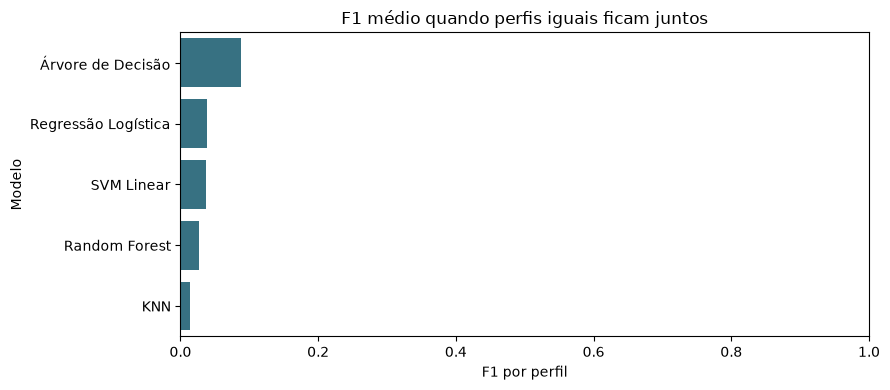

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate

scoring = {
    "recall": "recall",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
}
cv_aleatoria = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_perfis = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resultados = []

for nome, modelo in modelos.items():
    scores_aleatorios = cross_validate(
        modelo, X_train, y_train, cv=cv_aleatoria, scoring=scoring, n_jobs=1
    )
    scores_perfis = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_perfis,
        groups=groups_train,
        scoring=scoring,
        n_jobs=1,
    )
    resultados.append({
        "Modelo": nome,
        "Recall aleatório": scores_aleatorios["test_recall"].mean(),
        "F1 aleatório": scores_aleatorios["test_f1"].mean(),
        "Balanced accuracy aleatória": scores_aleatorios["test_balanced_accuracy"].mean(),
        "Recall por perfil": scores_perfis["test_recall"].mean(),
        "F1 por perfil": scores_perfis["test_f1"].mean(),
        "Balanced accuracy por perfil": scores_perfis["test_balanced_accuracy"].mean(),
    })

df_resultados = pd.DataFrame(resultados).sort_values("F1 por perfil", ascending=False)
display(df_resultados.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=df_resultados, x="F1 por perfil", y="Modelo", color="#2a788e", ax=ax)
ax.set_xlim(0, 1)
ax.set_title("F1 médio quando perfis iguais ficam juntos")
fig.tight_layout()
fig.savefig(FIGURES / "05_comparacao_modelos.png", dpi=160, bbox_inches="tight")
plt.show()
df_resultados.to_csv(METRICS_DIR / "validacao_cruzada.csv", index=False)

## 4. Resultado da comparação

Com os nomes padronizados em português e as idades/tempos em anos, os modelos mantêm o mesmo comportamento geral. Quando mantenho os perfis juntos, o F1 é menor. A Árvore de Decisão teve o maior F1 por perfil (0,089), seguida pela Regressão Logística e pela SVM linear (cerca de 0,038 cada). Regressão Logística e SVM encontraram mais clientes com atraso grave (recall de aproximadamente 0,46), mas também geram muitos falsos alertas. Escolhi a Árvore de Decisão pelo maior F1 agrupado. Se o banco preferir priorizar recall, será necessário aceitar e avaliar esse aumento de alertas.

In [6]:
best_model_name = df_resultados.iloc[0]["Modelo"]
best_model = modelos[best_model_name]
best_model.fit(X_train, y_train)

MODEL_DIR = Path("..") / "results" / "models"
METRICS_DIR = Path("..") / "results" / "metrics"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

import joblib

joblib.dump(best_model, MODEL_DIR / "best_model.joblib")
df_resultados.to_csv(METRICS_DIR / "validacao_cruzada.csv", index=False)
print(f"Modelo selecionado: {best_model_name}")
print(f"Artefato salvo em: {MODEL_DIR / 'best_model.joblib'}")

Modelo selecionado: Árvore de Decisão
Artefato salvo em: ..\results\models\best_model.joblib
